# Petri-Net Based ABMs

First we want to load our packages with `using`

In [ ]:
using AlgebraicABMs, Catlab
using AlgebraicPetri
using Distributions, Makie, CairoMakie
ENV["JULIA_DEBUG"] = ""; # turn off @debug messages for this package

## Define the model

We define an SIRS model with birth and death

In [2]:
sir_pn= @acset LabelledPetriNet begin
  S=3; sname=[:S,:I,:R]
  T=7; tname=[:inf,:rec,:birth,:deathS,:deathI,:deathR,:wane]
  I=7; it=[1,1,2,4,5,6,7]; is=[1,2,2,1,2,3,3]
  O=5; ot=[1,1,2,3,7]; os=[2,2,3,1,1]
end;

We declare parameters to specify the random waiting times

In [3]:
pS, pI, pR = 95,5,0
pop = 100
lifespan = 65*365
μ = 1/lifespan
β = 0.001
wane = 60;

## Create the Model

Create the ABM by associating stochastic timers with each transition

In [4]:
abm = ABM(sir_pn, (inf=ContinuousHazard(1 / β),
                   rec=ContinuousHazard(Weibull(weibullpar(30, 5)...)),
                   birth=ContinuousHazard(1 / (μ*pop)),
                   deathS=ContinuousHazard(1 / μ),
                   deathI=ContinuousHazard(1 / μ),
                   deathR=ContinuousHazard(1 / μ),
                   wane=ContinuousHazard(wane)));

## Initial State

In [5]:
init = PetriNetCSet(sir_pn; S=pS, I=pI)

AnonACSet{TypeLevelBasicSchema{Symbol, Tuple{:S, :I, :R}, Tuple{}, Tuple{}, Tuple{}, Tuple{}}, Tuple{}, @NamedTuple{S::IntParts, I::IntParts, R::IntParts}, @NamedTuple{}, IntParts} {S:95, I:5, R:0}

## Run the Model

In [6]:
res = run!(abm, init; maxtime=2000);

## Plot the results

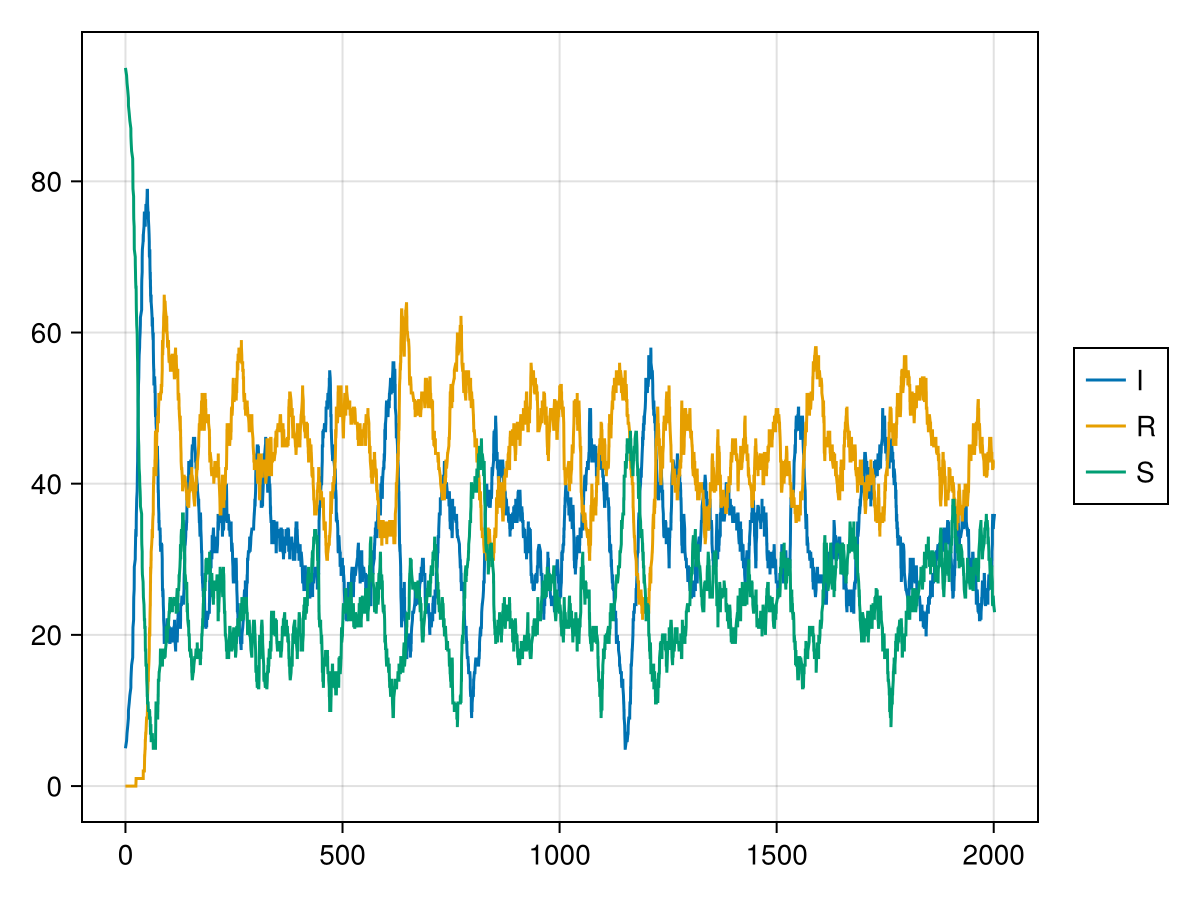

In [7]:
Makie.plot(res; Dict(o=>X->nparts(X,o) for o in [:S,:I,:R])...)